# Oncogenicity prediction for population-enriched variants

This notebook applied a combined variant-effect model to variants identified as enriched in specific population groups, and produces one oncogenicity prediction per variant.

## Design

All merges are left joins onto 'fvar', the deduplicated set set of 109, 471 Fisher variants. Row count is constant from that point through to the export, each merge adds columns only. 

Three strucutres operates in parallel:

1. **Variant table** — `fvar` → `m` → `m2` → `m3` → `res`. 109,471 rows throughout, widening from 5 columns to the exported set.
2. **Training set** - 'onco' -> 'train' -> 'lab'. 3,575 labeled missense variants. Disjoint from the variant table; the two are connected at a single point, the call to `predict_proba` in Part 5.
3. **Router** — partitions the variant table into five routes, each assigned a different
   prediction mechanism.

Variants recorded as `unmatched` are retained in the table with null values in every column sourced from `onco`. No rows are removed after the initial deduplication.


## Contents

| Part | Contents |
|---|---|
| 1 | Setup and load |
| 2 | Build the variant table |
| 3 | Route |
| 4 | Train the model |
| 5 | Score |
| 6 | Export |
| 7 | Checks |

Parts 1–6 produce the output file. Part 7 verifies assumptions and characterises decisions made in Parts 1–6.

| File | Object | Contents |
|---|---|---|
| `exonic_toolscores_oncokb_apicall.txt` | `onco` | Exonic variants with nine prediction-tool scores and OncoKB oncogenicity labels |
| `sites_biallelic_exome.indels.vep112_loftee.plof_calls.tsv` | `loftee` | LOFTEE loss-of-function calls for indels |
| `fisher_enrichment_results.tsv.gz` | `fisher` | Population-enrichment test results |
| `hersh_exome_biallelic_annovar_annotated.hg38_multianno.missense_ref_alt_chrom_position_gene_clinvar.tsv` | `clinvar` | ClinVar clinical significance |

## Output

`fisher_predictions.tsv.gz` — one row per variant, comprising variant identity, enrichment
statistics, assigned route, predicted probability and calls at two thresholds.

In [1]:
import pandas as pd, numpy as np, ast

# input files 
F_ONCO    = "exonic_toolscores_oncokb_apicall.txt"
F_LOFTEE  = "sites_biallelic_exome.indels.vep112_loftee.plof_calls.tsv"
F_FISHER  = "fisher_enrichment_results.tsv.gz"
F_CLINVAR = ("hersh_exome_biallelic_annovar_annotated.hg38_multianno."
             "missense_ref_alt_chrom_position_gene_clinvar.tsv")
F_OUT     = "fisher_predictions.tsv.gz"

#  merge key 
KEY = ["Chr", "Start", "Ref", "Alt"]

#  tool panels 
# All nine tools as named in the annotated file.
TOOL_COLS = ["VEST4_score", "REVEL_score", "MutPred_score", "PrimateAI_score",
             "VARITY_R_score", "VARITY_ER_score", "ESM1b_score", "EVE_score",
             "AlphaMissense_score"]

# The eight features supplied to the model. VARITY_ER is excluded: it correlates 0.95
# with VARITY_R, and retaining both produced offsetting coefficients in earlier linear
# models. Order is significant, because .values discards column names and the model
# identifies features by position; training and scoring must index this same list.
MODEL_TOOLS = ["VEST4_score", "REVEL_score", "MutPred_score", "PrimateAI_score",
               "VARITY_R_score", "ESM1b_score", "EVE_score", "AlphaMissense_score"]

#  label definitions 
POS_LABELS    = ["Oncogenic", "Likely Oncogenic"]                      # OncoKB  -> 1
NEUTRAL_LABEL = "Likely Neutral"                                        # OncoKB  -> 0
BENIGN_LABELS = ["Benign", "Likely_benign", "Benign/Likely_benign"]     # ClinVar -> 0
MISSENSE      = "nonsynonymous SNV"

#  routing 
# ANNOVAR classes representing loss-of-function mechanisms. This list defines the
# variants for which LOFTEE may hold a verdict, not the variants classified as
# loss-of-function: startloss and stoploss appear here but are left unpredicted.
LOF_TYPES = ["frameshift deletion", "frameshift insertion", "stopgain",
             "startloss", "stoploss"]

#  model 
N_SPLITS      = 5
RANDOM_STATE  = 0

#  enrichment columns in the Fisher file 
ENR_POP, ENR_CMP = "focal_pop", "comparison"
ENR_OR,  ENR_P   = "odds_ratio", "p_adjusted"
SIG_ALPHA        = 0.05

print("config loaded |", len(TOOL_COLS), "tools read,", len(MODEL_TOOLS), "used by the model")

config loaded | 9 tools read, 8 used by the model


## 1.2 Helper functions

### Coordinate notation

The LOFTEE output and the Fisher results use VCF notation; the annotated reference file
uses ANNOVAR notation. Merging across the two without conversion returns zero matches and
raises no error.

VCF represents an indel with an unchanged **anchor base** included in both the reference
and alternate fields, so that neither field is empty. ANNOVAR names only the bases that
change, and writes `-` for absence.

The two branches use different coordinate arithmetic because ANNOVAR anchors deletions and
insertions on different positions. For a deletion, `Start` is the first deleted base, which
lies immediately past the anchor: `pos + len(alt)`. For an insertion, `Start` is the last
unchanged base preceding the insertion point, because inserted bases have no reference
coordinate of their own: `pos + len(ref) - 1`.

### Functions defined here

| Function | Purpose |
|---|---|
| `vcf_to_annovar` | Convert a single variant from VCF to ANNOVAR notation |
| `violates_prefix` | Identify variants whose allele lengths differ while neither allele is a prefix of the other. Used in 7.1 |
| `apply_conversion` | Apply `vcf_to_annovar` across a DataFrame and return an aligned three-column result. Used in 1.3, 2.3 and 6.1 |

In [2]:
def vcf_to_annovar(pos, ref, alt):
    """Convert VCF (anchored) notation to ANNOVAR (changed bases only).

    Returns (Start, Ref, Alt). SNVs are returned unchanged.
    """
    pos, ref, alt = int(pos), str(ref), str(alt)
    if len(ref) > len(alt):                       # deletion: alt is the anchor
        return pos + len(alt), ref[len(alt):], "-"
    elif len(alt) > len(ref):                     # insertion: ref is the anchor
        return pos + len(ref) - 1, "-", alt[len(ref):]
    return pos, ref, alt                          # identical in both notations


def violates_prefix(ref, alt):
    """True if the allele lengths differ but neither string is a prefix of the other.

    Such variants break the anchor assumption in vcf_to_annovar and would be
    mis-converted without error.
    """
    r, a = str(ref), str(alt)
    if len(r) == len(a):
        return False
    short, long_ = (a, r) if len(r) > len(a) else (r, a)
    return not long_.startswith(short)


def apply_conversion(df, pos_col, ref_col, alt_col, index=None):
    """Apply vcf_to_annovar row-wise and return a DataFrame aligned to df.

    The index argument is required when converting a subset of rows, so that the
    result aligns to the original row labels rather than to a fresh range.
    """
    conv = df.apply(lambda r: vcf_to_annovar(r[pos_col], r[ref_col], r[alt_col]), axis=1)
    return pd.DataFrame(conv.tolist(),
                        index=df.index if index is None else index,
                        columns=["Start", "Ref", "Alt"])


# sanity check on the two documented cases
assert vcf_to_annovar(100, "CTTT", "C")  == (101, "TTT", "-")
assert vcf_to_annovar(100, "C", "CAT")   == (100, "-", "AT")
assert vcf_to_annovar(100, "A", "G")     == (100, "A", "G")
print("helper functions defined; notation conversion verified on the documented cases")

helper functions defined; notation conversion verified on the documented cases


## 1.3 Load the three sources

Reads the annotated reference, the LOFTEE calls and the Fisher enrichment results, and
parses each into the common `Chr / Start / Ref / Alt` key. The LOFTEE coordinates are
converted to ANNOVAR notation here so that they merge against `onco` in Part 2.

### Filters applied

| Expression | Effect | Rationale |
|---|---|---|
| `ANNOTATED == True` | Restricts `onco` to variants for which the OncoKB API returned an annotation | Defines the universe for both the training set and the variant table. It is the reason 94,393 Fisher variants are later recorded as `unmatched` |
| `errors="coerce"` | Non-numeric tool scores become NaN | dbNSFP records missing values as `"."`; coercion prevents these being retained as strings |
| `mane_select != "."` | Restricts `loftee` to MANE Select transcript calls | A variant may receive different LOFTEE verdicts on different transcripts. This selects one canonical transcript rather than taking the most severe consequence across all transcripts |
| `drop_duplicates("variant_id")` | Retains the first row per variant | Ordering is that of the source file |

### Notes

`fisher` retains all 392,127 rows. Each variant appears once per population × comparison
tested, and the export in Part 6 requires every test in order to collapse them by
significance. The deduplicated view is created separately in 2.1.

`locus` and `alleles` are stored as text representations of Hail objects — `"chr1:12345"`
and `"['C', 'T']"` respectively. `ast.literal_eval` parses the allele field; it accepts
literals only and will not execute code.

### Expected output

| Object | Rows |
|---|---|
| `onco` | 169,360 |
| `loftee` | 7,056 |
| `fisher` | 392,127 rows, 109,471 distinct variants |

In [3]:
# ---- annotated reference: tool scores, variant class, OncoKB label ----
onco = pd.read_csv(F_ONCO, sep="\t", low_memory=False)
onco = onco[onco["ANNOTATED"] == True]
for c in TOOL_COLS:
    onco[c] = pd.to_numeric(onco[c], errors="coerce")

# ---- LOFTEE calls, converted to ANNOVAR notation ----
lof  = pd.read_csv(F_LOFTEE, sep="\t", low_memory=False)
lof1 = lof[lof["mane_select"] != "."].drop_duplicates("variant_id").copy()
lof1["Chr"] = lof1["chrom"]
lof1[["Start", "Ref", "Alt"]] = apply_conversion(lof1, "pos", "ref", "alt")
loftee = lof1[KEY + ["loftee_lof"]]

# ---- population-enrichment results ----
fisher = pd.read_csv(F_FISHER, sep="\t", low_memory=False)
locus_parts     = fisher["locus"].str.split(":")
fisher["Chr"]   = locus_parts.str[0]
fisher["Start"] = locus_parts.str[1].astype(int)
parsed          = fisher["alleles"].apply(ast.literal_eval)
fisher["Ref"]   = parsed.str[0]
fisher["Alt"]   = parsed.str[1]

print("onco   :", len(onco), "rows")
print("loftee :", len(loftee), "rows")
print("fisher :", len(fisher), "rows |",
      fisher[KEY].drop_duplicates().shape[0], "distinct variants")

onco   : 169360 rows
loftee : 7056 rows
fisher : 392127 rows | 109471 distinct variants


---
# Part 2 — Build the variant table

Rows are fixed at 109,471 from 2.1 through to the export. Columns grow from 5 to 20.

## 2.1 Deduplicate and flag indels

`fisher` holds one row per variant per population × comparison. Reducing to distinct
variants is the only change in row count anywhere in the notebook: 392,127 → 109,471.

`is_indel` flags a difference in allele string length. Only these rows require notation
conversion in 2.3; the flag also persists downstream, which is what allows match rates to
be reported separately for SNVs and indels.

**Expected output:** 109,471 distinct variants — 108,726 SNVs, 745 indels.


In [4]:
fvar = fisher[KEY].drop_duplicates().copy()

r = fvar["Ref"].astype(str)
a = fvar["Alt"].astype(str)
fvar["is_indel"] = (r.str.len() != a.str.len())

print("distinct variants:", len(fvar))
print("  SNVs  :", int((~fvar["is_indel"]).sum()))
print("  indels:", int(fvar["is_indel"].sum()))

distinct variants: 109471
  SNVs  : 108726
  indels: 745


## 2.2 Merge against the annotated reference

Left join onto `onco`, adding gene, variant class, OncoKB label and the nine tool scores.

`how="left"` retains all 109,471 rows regardless of match. An inner join would return 14,622
and discard the variants the export must still report as unpredicted.

`matched` is inferred from `ExonicFunc` being non-null rather than returned by the merge:
after a left join, unmatched rows carry NaN in every column drawn from the right table.

**Expected output:** 14,622 matched. SNVs 14,622 of 108,726 (13.4%); **indels 0 of 745**,
a notation mismatch addressed in 2.3.

In [5]:
keep = KEY + ["Gene.refGeneWithVer", "Func.refGeneWithVer",
              "ExonicFunc.refGeneWithVer", "ONCOGENIC"] + TOOL_COLS

m = fvar.merge(onco[keep], on=KEY, how="left")
m["matched"] = m["ExonicFunc.refGeneWithVer"].notna()

print("matched:", int(m["matched"].sum()), "of", len(m))
print(m.groupby("is_indel")["matched"].agg(["sum", "count", "mean"]).round(3))
print("\nvariant classes among matched:")
print(m.loc[m["matched"], "ExonicFunc.refGeneWithVer"].value_counts())

matched: 14622 of 109471
            sum   count   mean
is_indel                      
False     14622  108726  0.134
True          0     745  0.000

variant classes among matched:
ExonicFunc.refGeneWithVer
nonsynonymous SNV    13926
stopgain               554
synonymous SNV          99
startloss               42
stoploss                 1
Name: count, dtype: int64


## 2.3 Convert indel notation and re-merge

Applies `vcf_to_annovar` to the 745 indel rows, then repeats the merge from 2.2 unchanged —
same key, same columns, same join type. Only the coordinate values differ, which makes the
before and after directly comparable.

`fvar = fvar.copy()` preserves the original VCF coordinates in `fvar`, but within
`fvar_conv` the `Start`, `Ref` and `Alt` columns are overwritten in place. Part 6 therefore
rebuilds the mapping between the two coordinate systems from `fisher`, rather than merging
back on these keys.

**Expected output:** indels 444 of 745 (59.6%). SNVs unchanged at 14,622, confirming the
conversion affected only the intended rows.

In [6]:
fvar_conv = fvar.copy()
idx = fvar_conv["is_indel"]

fvar_conv.loc[idx, ["Start", "Ref", "Alt"]] = apply_conversion(
    fvar_conv.loc[idx], "Start", "Ref", "Alt")

m2 = fvar_conv.merge(onco[keep], on=KEY, how="left")
m2["matched"] = m2["ExonicFunc.refGeneWithVer"].notna()

print(m2.groupby("is_indel")["matched"].agg(["sum", "count", "mean"]).round(3))
print("\nvariant classes among matched:")
print(m2.loc[m2["matched"], "ExonicFunc.refGeneWithVer"].value_counts())

            sum   count   mean
is_indel                      
False     14622  108726  0.134
True        444     745  0.596

variant classes among matched:
ExonicFunc.refGeneWithVer
nonsynonymous SNV          13926
stopgain                     586
frameshift deletion          279
frameshift insertion         114
synonymous SNV                99
startloss                     42
nonframeshift deletion        17
nonframeshift insertion        2
stoploss                       1
Name: count, dtype: int64


## 2.4 Attach LOFTEE calls

Third left join, adding one column: `loftee_lof`, taking values `HC`, `LC` or NaN.

This merge depends on the conversion applied to `loftee` in 1.3 — both sides now carry
ANNOVAR coordinates.

Coverage by variant class is reported in 7.3, and is what determines the routing in Part 3.

**Expected output:** 109,471 rows, 20 columns, `loftee_lof` non-null on 437.

In [7]:
m3 = m2.merge(loftee, on=KEY, how="left")

print("rows:", len(m3), "| columns:", m3.shape[1])
print("loftee_lof non-null:", int(m3["loftee_lof"].notna().sum()))

rows: 109471 | columns: 20
loftee_lof non-null: 437


---
# Part 3 — Route

## 3.1 Assign a prediction route

Each variant is assigned to one of five routes. The two routes that require no model are
filled in the same cell.

| Route | n | Mechanism |
|---|---|---|
| `unmatched` | 94,393 | Absent from the annotated reference; no tool scores exist |
| `model` | 13,925 | Missense with at least one tool score; scored in Part 5 |
| `rule_lof` | 555 | Stopgain with no LOFTEE verdict; set to 1 by rule |
| `loftee` | 437 | LOFTEE verdict present; HC → 1, LC → 0 |
| `no_prediction` | 161 | Synonymous, in-frame indels, startloss, stoploss, and one missense variant with no tool scores |

### Decisions

**Priority order.** LOFTEE is tested first, so a LOFTEE verdict takes precedence over the
model. Section 7.3 confirms that no missense variant is diverted by this ordering.

**Stopgain by rule.** LOFTEE was run against an indels-only file, leaving 555 of 586
stopgains without a verdict (7.3). A premature stop codon is presumed damaging under ACMG
PVS1 and is set to 1 without a model. It is held as a separate route so that these calls
remain distinguishable from model predictions.

**startloss and stoploss are left unpredicted**, despite also lacking tool coverage. The
functional consequence is less certain than for a premature stop codon.

**Missense variants with no tool scores are left unpredicted.** One variant meets this
condition. Given no features, the model returns the base rate of the training set, which
describes the training data rather than the variant.

**Expected output:** the counts above; `call` filled on 992 rows.

In [8]:
res = m3.copy()

def assign_route(row):
    if pd.notna(row.get("loftee_lof")):
        return "loftee"                    # LOFTEE verdict takes precedence
    et = row["ExonicFunc.refGeneWithVer"]
    if et == MISSENSE:
        # no tool scores means no features for the model to use
        return "model" if row[MODEL_TOOLS].notna().any() else "no_prediction"
    if et == "stopgain":
        return "rule_lof"                  # truncating, no LOFTEE verdict
    if pd.isna(et):
        return "unmatched"                 # absent from the annotated reference
    return "no_prediction"                 # synonymous, in-frame, startloss, stoploss

res["route"] = res.apply(assign_route, axis=1)

# fill the two routes that require no model
res["call"] = np.nan
res.loc[res["route"] == "loftee", "call"] = (
    res.loc[res["route"] == "loftee", "loftee_lof"].eq("HC").astype(int))
res.loc[res["route"] == "rule_lof", "call"] = 1

print(res["route"].value_counts())
print("\ncall filled on", int(res["call"].notna().sum()), "rows")

route
unmatched        94393
model            13925
rule_lof           555
loftee             437
no_prediction      161
Name: count, dtype: int64

call filled on 992 rows


---
# Part 4 — Train the model

The training set is built from `onco` and ClinVar. It is disjoint from the variant table
constructed in Part 2; the two are connected only by the call to `predict_proba` in Part 5.

## 4.1 Build the training labels

Three boolean masks are defined across all rows of `train`, then combined into a filter:

| Mask | Definition |
|---|---|
| `pos` | OncoKB records Oncogenic or Likely Oncogenic |
| `neg` | OncoKB records Likely Neutral, **or** ClinVar records benign |
| `missense` | Variant class is nonsynonymous SNV, the only class the tools score |

`lab` retains missense variants satisfying either `pos` or `neg`. The label is then set from
`pos` alone: `neg` determines eligibility for the training set, but once a variant is
included, anything not positive is negative by default. Variants satisfying both conditions
— OncoKB oncogenic and ClinVar benign — resolve to positive; their number is reported in 7.2.

`pos[lab.index]` selects mask values by original index label rather than by position, which
is what keeps each label attached to the correct variant after filtering.

ClinVar is included because OncoKB alone supplies only 219 neutral missense variants, too
few to form a negative class. The consequence for interpreting per-tool results is recorded
in 7.2.

**Expected output:** 3,575 labeled variants — 824 positive, 2,751 negative. Approximately
2% of the annotated variants carry a usable label.

In [9]:
clinvar = pd.read_csv(F_CLINVAR, sep="\t", low_memory=False)
clv = (clinvar[["Chrom", "Position", "Ref", "Alt", "ClinVar_CLNSIG"]]
       .rename(columns={"Chrom": "Chr", "Position": "Start"}))
train = onco.merge(clv, on=KEY, how="left")

pos      = train["ONCOGENIC"].isin(POS_LABELS)
neg      = (train["ONCOGENIC"] == NEUTRAL_LABEL) | train["ClinVar_CLNSIG"].isin(BENIGN_LABELS)
missense = train["ExonicFunc.refGeneWithVer"] == MISSENSE

lab = train[missense & (pos | neg)].copy()
lab["label"] = pos[lab.index].astype(int)

print("training set:", len(lab),
      "| positive:", int(lab["label"].sum()),
      "| negative:", int((lab["label"] == 0).sum()))

training set: 3575 | positive: 824 | negative: 2751


## 4.2 Fit the model and select a threshold

This cell performs two separate operations.

**Building the model** is a single line: `final_model = hgb.fit(X, y)`, trained on all 3,575
labeled variants. This is the model applied in Part 5.

**Measuring it** requires five additional models. Each is trained on four fifths of the data
and predicts the fifth it did not see; the results are reassembled into `proba_cv`, giving
one prediction per training variant from a model that never saw that variant. These five
models are then discarded. They exist only to produce two quantities: the cross-validated
AUROC, and the threshold. The measurement must run while `hgb` is still unfitted, which is
why the final fit is the last line.

### Threshold selection

`roc_curve` evaluates every candidate cutoff and returns three aligned arrays: the cutoff
(`thr`), the fraction of true positives captured (`tpr`), and the fraction of negatives
wrongly flagged (`fpr`). Youden's J is `tpr - fpr`. `argmax` returns the index of the largest
value, and `thr` is read at that index.


In [10]:
# sklearn imports for Parts 4, 5 and 7
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

X = lab[MODEL_TOOLS].values      # NaNs retained; HGB routes them natively
y = lab["label"].values

cv  = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

# measurement: five clones, each predicting the fold it did not train on
proba_cv = cross_val_predict(hgb, X, y, cv=cv, method="predict_proba")[:, 1]
print("CV AUROC:", round(roc_auc_score(y, proba_cv), 3))

fpr, tpr, thr = roc_curve(y, proba_cv)
k = int((tpr - fpr).argmax())
THRESHOLD = float(thr[k])

# operating point at that threshold, on the training distribution
n_pos, n_neg = int(y.sum()), int((y == 0).sum())
precision_at = tpr[k] * n_pos / (tpr[k] * n_pos + fpr[k] * n_neg)
print(f"Youden threshold: {THRESHOLD:.4f}")
print(f"  recall    {tpr[k]:.3f}")
print(f"  precision {precision_at:.3f}")

# the model applied in Part 5
final_model = hgb.fit(X, y)

CV AUROC: 0.898
Youden threshold: 0.1397
  recall    0.824
  precision 0.574


---
# Part 5 — Score

## 5.1 Score the missense route

Applies `final_model` to the 13,926 missense variants and converts each probability to a
call at `THRESHOLD`.


`n_tools` records how many of the eight tools produced a score for each variant. It is not a
model input. It is initialised to NaN across all rows and filled only on the model route, so
that variants outside that route read as not applicable rather than as having zero tools.

In [11]:
mask_model = res["route"] == "model"

X_score = res.loc[mask_model, MODEL_TOOLS].values
res.loc[mask_model, "probability"] = final_model.predict_proba(X_score)[:, 1]
res.loc[mask_model, "call"] = (res.loc[mask_model, "probability"] >= THRESHOLD).astype(int)

res["n_tools"] = np.nan
res.loc[mask_model, "n_tools"] = res.loc[mask_model, MODEL_TOOLS].notna().sum(axis=1)

print(res.groupby("route")["call"].agg(n="size", called="sum", rate="mean").round(3))
print()
print(res.loc[mask_model, "probability"].describe().round(3))

                   n  called   rate
route                              
loftee           437   426.0  0.975
model          13925  7394.0  0.531
no_prediction    161     0.0    NaN
rule_lof         555   555.0  1.000
unmatched      94393     0.0    NaN

count    13925.000
mean         0.287
std          0.294
min          0.000
25%          0.035
50%          0.166
75%          0.495
max          0.998
Name: probability, dtype: float64


---
# Part 6 — Export

## 6.1 Assemble one row per variant and write

The three sources were combined in Part 2. What this cell recovers is the enrichment
statistics, which were discarded at 2.1 when `fisher` was reduced to its four key columns.
`res` carries the predictions, `enr` carries the enrichment results collapsed to one row per
variant, and this cell joins them.

Two complications:

**Coordinate systems.** `res` holds ANNOVAR coordinates for indels, because 2.3 overwrote
them in place, while `fisher` still holds VCF coordinates. Merging the two directly returns
null predictions for every matched indel and raises nothing. A mapping between the two
systems is therefore rebuilt from `fisher`, and both are retained in the output:
`Chr / Start / Ref / Alt` are the original VCF coordinates, and
`Start_annovar / Ref_annovar / Alt_annovar` allow the join to be audited.

**Repeated rows.** `fisher` records one row per variant per population × comparison. Sorting
by adjusted p-value and taking the first row per variant retains the strongest enrichment;
`n_tests`, `n_sig_tests` and `enriched_pops` preserve what was collapsed

In [12]:
# --- 1. map VCF coordinates (fisher) to ANNOVAR coordinates (res) ---
kmap = (fisher[KEY].drop_duplicates()
          .rename(columns={"Start": "Start_o", "Ref": "Ref_o", "Alt": "Alt_o"})
          .reset_index(drop=True))
ind = kmap["Ref_o"].astype(str).str.len() != kmap["Alt_o"].astype(str).str.len()
kmap[["Start", "Ref", "Alt"]] = kmap[["Start_o", "Ref_o", "Alt_o"]].values
kmap.loc[ind, ["Start", "Ref", "Alt"]] = apply_conversion(
    kmap.loc[ind], "Start_o", "Ref_o", "Alt_o")
kmap["Start"] = kmap["Start"].astype(int)
print("key map:", kmap.shape, "| indels converted:", int(ind.sum()))

# --- 2. collapse enrichment to one row per variant ---
f = fisher.sort_values(ENR_P)
enr = (f.groupby(KEY, as_index=False)
         .agg(top_focal_pop=(ENR_POP, "first"), top_comparison=(ENR_CMP, "first"),
              top_odds_ratio=(ENR_OR, "first"), min_p_adjusted=(ENR_P, "first"),
              n_tests=(ENR_P, "size"),
              n_sig_tests=(ENR_P, lambda s: int((s < SIG_ALPHA).sum()))))
sig = (f[f[ENR_P] < SIG_ALPHA].groupby(KEY)[ENR_POP]
         .agg(lambda s: ";".join(sorted(set(s.astype(str)))))
         .rename("enriched_pops").reset_index())
enr = (enr.merge(sig, on=KEY, how="left")
          .rename(columns={"Start": "Start_o", "Ref": "Ref_o", "Alt": "Alt_o"}))

# --- 3. attach predictions on the converted key ---
pred_cols = KEY + ["Gene.refGeneWithVer", "ExonicFunc.refGeneWithVer",
                   "route", "probability", "call", "n_tools"]

final = (enr.merge(kmap, on=["Chr", "Start_o", "Ref_o", "Alt_o"], how="left")
            .merge(res[pred_cols], on=KEY, how="left"))
final["route"] = final["route"].fillna("unmatched")
for c in ["call", "n_tools"]:
    final[c] = final[c].astype("Int64")

final = final.rename(columns={"Start_o": "Start", "Ref_o": "Ref", "Alt_o": "Alt",
                              "Start": "Start_annovar", "Ref": "Ref_annovar",
                              "Alt": "Alt_annovar"})
front = ["Chr", "Start", "Ref", "Alt", "Gene.refGeneWithVer",
         "ExonicFunc.refGeneWithVer", "route", "probability", "call", "n_tools"]
final = final[front + [c for c in final.columns if c not in front]]

# --- 4. verify, then write ---
assert len(final) == 109471, f"row count changed: {len(final)}"
assert final[["Chr", "Start", "Ref", "Alt"]].duplicated().sum() == 0, "duplicate variants"
assert final["probability"].notna().sum() == int(mask_model.sum()), \
    "probability present outside the model route"

print("\n", final.groupby("route").size(), sep="")
is_ind = final["Ref"].astype(str).str.len() != final["Alt"].astype(str).str.len()
print("\nindels total         :", int(is_ind.sum()))
print("indels with a call   :", int(final.loc[is_ind, "call"].notna().sum()))
print("variants with a call :", int(final["call"].notna().sum()))
print("with a probability   :", int(final["probability"].notna().sum()))

final.to_csv(F_OUT, sep="\t", index=False, compression="gzip")
print("\nwrote", F_OUT, final.shape)


cols = ["Chr", "Start", "Ref", "Alt", "Gene.refGeneWithVer",
        "ExonicFunc.refGeneWithVer", "route", "probability", "call", "n_tools",
        "top_focal_pop", "min_p_adjusted"]
display(final.loc[(final["route"] == "model") & (final["n_tools"] < 5), cols]
             .sort_values("probability", ascending=False)
             .head(20))

key map: (109471, 7) | indels converted: 745

route
loftee             437
model            13925
no_prediction      161
rule_lof           555
unmatched        94393
dtype: int64

indels total         : 745
indels with a call   : 438
variants with a call : 14917
with a probability   : 13925

wrote fisher_predictions.tsv.gz (109471, 20)


,Chr,Start,Ref,Alt,Gene.refGeneWithVer,ExonicFunc.refGeneWithVer,route,probability,call,n_tools,top_focal_pop,min_p_adjusted
28031,chr13,32370421,G,A,BRCA2,nonsynonymous SNV,model,0.601132,1,4,Non Jew European,3.379663e-01
25522,chr12,120994312,G,T,HNF1A,nonsynonymous SNV,model,0.546157,1,4,Non Jew European,7.624386e-10
28045,chr13,32370992,C,T,BRCA2,nonsynonymous SNV,model,0.505167,1,4,African ancestry1,1.104931e-01
27876,chr13,32337387,C,G,BRCA2,nonsynonymous SNV,model,0.364867,1,4,Mexican,2.548809e-02
66500,chr22,28724922,T,G,CHEK2,nonsynonymous SNV,model,0.354644,1,3,Mexican,3.516860e-05
28030,chr13,32370420,C,T,BRCA2,nonsynonymous SNV,model,0.329547,1,4,Filipino,1.867762e-05
28067,chr13,32379828,T,C,BRCA2,nonsynonymous SNV,model,0.314995,1,4,Non Jew European,3.646734e-03
25557,chr12,120997569,C,T,HNF1A,nonsynonymous SNV,model,0.297880,1,4,Non Jew European,1.720053e-10
25493,chr12,120988847,G,A,HNF1A,nonsynonymous SNV,model,0.285529,1,4,African ancestry1,6.134763e-04
25566,chr12,120999307,A,G,HNF1A,nonsynonymous SNV,model,0.279676,1,4,Ashkenazi Jewish,4.761622e-224


Predicted probability by tool coverage

Probability does not rise monotonically with the number of tools, which rules out a simple
evidence-quantity effect. What the table does show is a ceiling: no variant with four or
fewer tool scores exceeds a probability of 0.640, while variants with five or more reach
0.999. The model emits a point estimate rather than an interval, so reduced evidence is
expressed as a lower probability rather than as wider uncertainty. Low-coverage variants
are therefore pushed toward benign rather than toward unknown.

187 variants have four or fewer tool scores.

In [13]:
display(res[mask_model].groupby("n_tools")["probability"]
           .agg(n="size", mean="mean", median="median", max="max").round(3))

,n,mean,median,max
n_tools,,,,
2.0,1,0.083,0.083,0.083
3.0,41,0.045,0.030,0.355
4.0,145,0.078,0.034,0.601
5.0,418,0.231,0.177,0.990
6.0,1956,0.125,0.031,0.993
7.0,5897,0.244,0.117,0.998
8.0,5467,0.403,0.365,0.998


---
# Part 7 — Tool contributions

SHAP splits each prediction into one contribution per tool, in log-odds. Positive pushes
toward oncogenic, negative toward benign. The contributions plus a baseline reconstruct the
model's output exactly, which the additivity check confirms.

**Read `when_observed`, not `mean_abs_shap`.** Coverage varies from 57% to 98%, and a tool
absent on half the rows contributes nothing on those rows, so its overall average understates
it. `when_observed` averages only where the tool actually produced a score.

**Compare within groups, not across.** VARITY_R, REVEL, VEST4 and MutPred were trained on
ClinVar, and 92% of the negative class is ClinVar-derived, so their contributions are
inflated relative to the other four. `clinvar_trained` marks them.

`signed_when_missing` shows how the model treats a tool's absence. It is only meaningful for
MutPred and EVE, the two with substantial missingness.

additivity max error: 1.60e-14


,tool,clinvar_trained,coverage,when_observed,signed_when_missing
0,VARITY_R_score,True,0.839,0.8987,0.2430
1,MutPred_score,True,0.568,0.7897,-0.9018
2,AlphaMissense_score,False,0.977,0.5047,0.0101
3,REVEL_score,True,0.959,0.4966,-0.1225
4,VEST4_score,True,0.977,0.4105,0.7777
5,ESM1b_score,False,0.867,0.4042,-0.0099
6,PrimateAI_score,False,0.934,0.2862,0.3777
7,EVE_score,False,0.610,0.2591,-0.1177


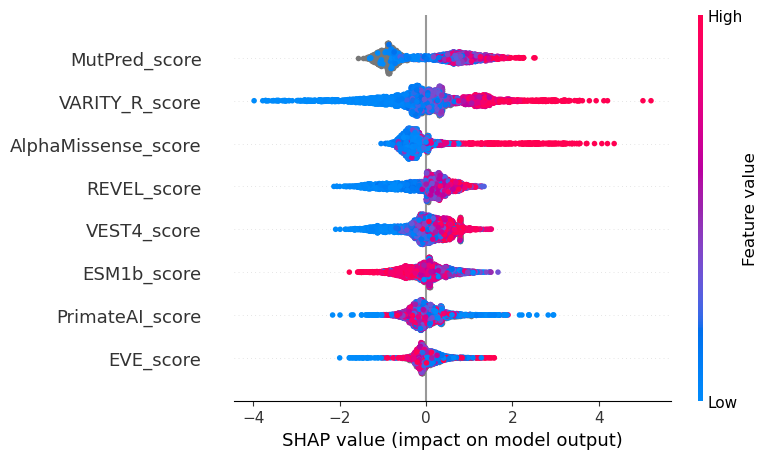

In [14]:
import shap, matplotlib.pyplot as plt, os

CLINVAR_TRAINED = {"VARITY_R_score", "REVEL_score", "VEST4_score", "MutPred_score"}
X_TRAIN = lab[MODEL_TOOLS]

explainer = shap.TreeExplainer(final_model)
sv = explainer(X_TRAIN)
S  = sv.values

recon = S.sum(axis=1) + np.asarray(sv.base_values).reshape(-1)
print("additivity max error:",
      f"{np.max(np.abs(recon - final_model.decision_function(X_TRAIN.values))):.2e}")

rows = []
for j, t in enumerate(MODEL_TOOLS):
    obs = X_TRAIN[t].notna().values
    rows.append({"tool": t,
                 "clinvar_trained": t in CLINVAR_TRAINED,
                 "coverage": round(obs.mean(), 3),
                 "when_observed": round(np.abs(S[obs, j]).mean(), 4),
                 "signed_when_missing": round(S[~obs, j].mean(), 4) if (~obs).any() else None})
display(pd.DataFrame(rows).sort_values("when_observed", ascending=False, ignore_index=True))

os.makedirs("figures", exist_ok=True)
shap.summary_plot(S, X_TRAIN, feature_names=MODEL_TOOLS, show=False)
plt.tight_layout()
plt.savefig("figures/shap_summary_missense.png", dpi=200, bbox_inches="tight")
plt.show()